In [1]:
import scanpy as sc
import scvi

sc.set_figure_params(figsize=(4, 4))

# for white background of figures (only for docs rendering)
%config InlineBackend.print_figure_kwargs={'facecolor' : "w"}
%config InlineBackend.figure_format='retina'

In [2]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad

In [3]:
adata_fus = sc.read_10x_mtx('../fused/',
                           var_names='gene_symbols',
                           cache=True)
adata_fus.obs["sample"] = "fused"
barcodes = adata_fus.obs.index
modified_barcodes = [f"F_{barcode}" for barcode in barcodes]
adata_fus.obs.index = modified_barcodes

In [4]:
adata_par = sc.read_10x_mtx('../parental/',
                           var_names='gene_symbols',
                           cache=True)
adata_par.obs["sample"]= "parental"
barcodes = adata_par.obs.index
modified_barcodes = [f"P_{barcode}" for barcode in barcodes]
adata_par.obs.index = modified_barcodes
#adata_par.obs

In [5]:
adata_res = sc.read_10x_mtx('../resistant/',
                           var_names='gene_symbols',
                           cache=True)
barcodes = adata_res.obs.index
modified_barcodes = [f"R_{barcode}" for barcode in barcodes]
adata_res.obs.index = modified_barcodes
adata_res.obs["sample"] = "resistant"
#adata_res.obs

In [6]:
adata_fus.var_names_make_unique()
adata_par.var_names_make_unique()
adata_res.var_names_make_unique()

print(adata_fus)
print(adata_par)
print(adata_res)

AnnData object with n_obs × n_vars = 6044 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 10353 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'
AnnData object with n_obs × n_vars = 8513 × 36601
    obs: 'sample'
    var: 'gene_ids', 'feature_types'


In [7]:
adata_combined = ad.concat([adata_fus, adata_par, adata_res])
#note genes are no longer unique I hope that's okay? Should check with Arda

In [8]:
sc.pp.filter_cells(adata_combined, min_genes=200)
sc.pp.filter_genes(adata_combined, min_cells=3)

In [9]:
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True) #Calculate QC metrics
adata_combined_filtered = adata_combined[adata_combined.obs.total_counts<75000,:]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.n_genes >1000, :]
adata_combined_filtered = adata_combined_filtered[adata_combined_filtered.obs.pct_counts_mt < 40, :]

In [10]:
adata_combined_filtered.layers["counts"] = adata_combined_filtered.X.copy()
sc.pp.normalize_total(adata_combined_filtered, target_sum=1e6)
sc.pp.log1p(adata_combined_filtered)
adata_combined_filtered.raw = adata_combined_filtered
sc.pp.highly_variable_genes(adata_combined_filtered, n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="sample",)

/tmp/job.3463093.pioneer/ipykernel_2345282/3390471787.py:1: ImplicitModificationWarning: Setting element `.layers['counts']` of view, initializing view as actual.
  adata_combined_filtered.layers["counts"] = adata_combined_filtered.X.copy()


In [11]:
scvi.model.SCVI.setup_anndata(
    adata_combined_filtered,
    layer = "counts",
    batch_key="sample"
)


In [15]:
model = scvi.model.SCVI(adata_combined_filtered)

model.train(accelerator='mps') #set to use GPU instead of CPU

/opt/anaconda3/envs/scvi-py3/lib/python3.10/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been set to `mps`. Please note that not all PyTorch/Jax operations are supported with this backend. as a result, some models might be slower and less accurate than usuall. Please verify your analysis!Refer to https://github.com/pytorch/pytorch/issues/77764 for more details.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/scvi-py3/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `n

Training:   0%|          | 0/331 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=331` reached.


In [16]:
SCVI_LATENT_KEY = "X_scVI"
adata_combined_filtered.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()


In [20]:
sc.pp.neighbors(adata_combined_filtered, use_rep=SCVI_LATENT_KEY)
sc.tl.leiden(adata_combined_filtered)


/var/folders/rw/jb2qbfc90ng7bxbn2nvy3sqw0000gn/T/ipykernel_32150/941144562.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_combined_filtered)


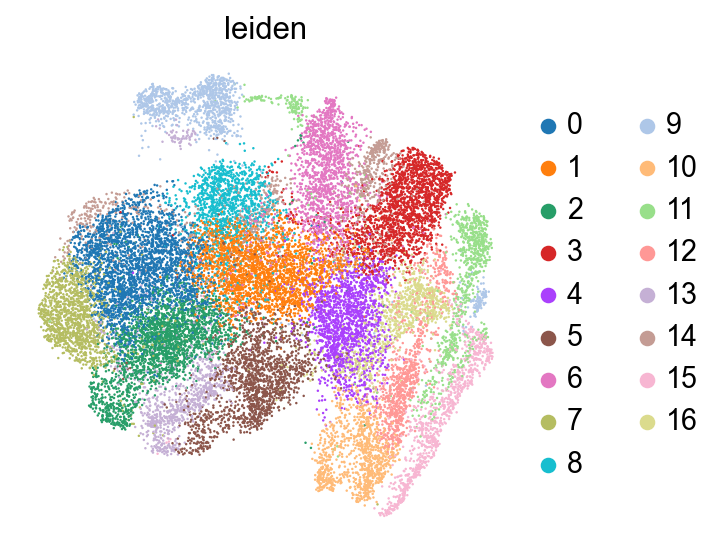

In [24]:
sc.tl.umap(adata_combined_filtered, min_dist=0.3)
sc.pl.umap(
    adata_combined_filtered,
    color=["leiden"],
    frameon=False,
    ncols=1,
)



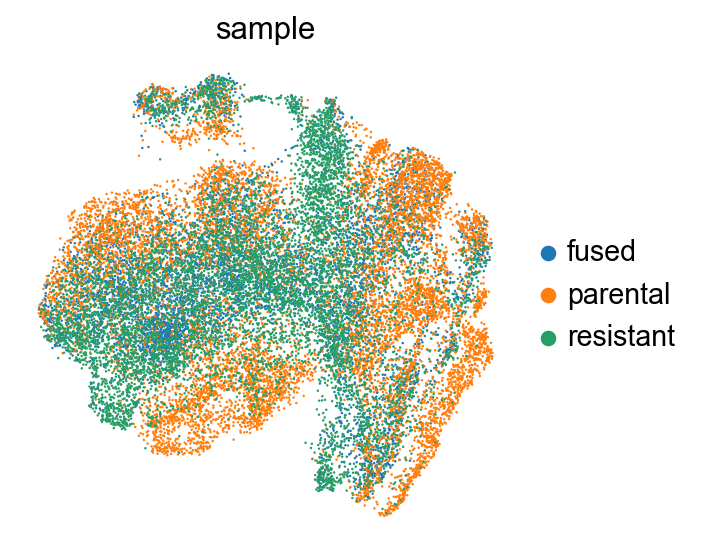

In [25]:
sc.pl.umap(
    adata_combined_filtered,
    color=["sample"],
    frameon=False,
    ncols=1,
)



In [30]:
# neighbors were already computed using scVI
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata_combined_filtered, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)


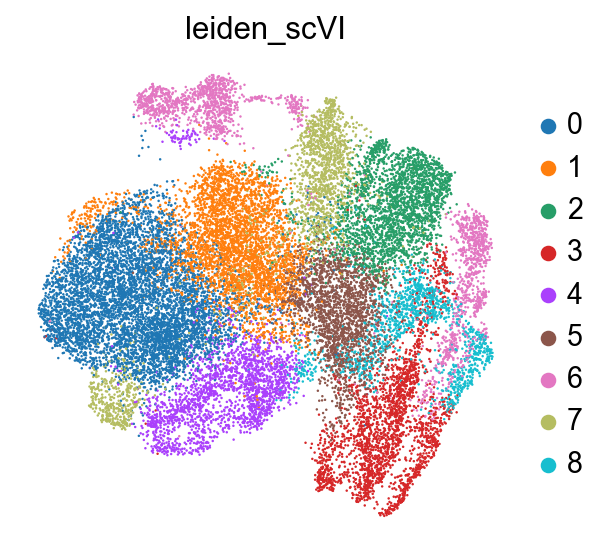

In [31]:
sc.pl.umap(
    adata_combined_filtered,
    color=[SCVI_CLUSTERS_KEY],
    frameon=False,
)



In [36]:
de_df = model.differential_expression(groupby="sample", mode="change")
de_df.head()

DE...:   0%|          | 0/3 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
TRIM29,0.9006,0.0994,2.203909,0.001018,0.000306,8.601872e-07,0.25,2.205304,1.883544,1.831371,...,2.479349,0.494942,0.783770,0.290528,10.630537,2.741384,False,fused vs Rest,fused,Rest
MUC13,0.8948,0.1052,2.140737,0.000052,0.000011,8.601872e-07,0.25,2.262017,2.297074,1.600195,...,0.006030,0.002826,0.003618,0.002772,0.021538,0.018083,False,fused vs Rest,fused,Rest
CXCL8,0.8740,0.1260,1.936798,0.000034,0.000185,8.601872e-07,0.25,-2.154092,-2.077377,1.747679,...,0.050310,0.283791,0.042040,0.120102,0.242703,1.540188,False,fused vs Rest,fused,Rest
PAK5,0.8684,0.1316,1.886885,0.000036,0.000009,8.601872e-07,0.25,1.974440,1.941643,1.541962,...,0.003446,0.003424,0.002412,0.003424,0.018929,0.019955,False,fused vs Rest,fused,Rest
CSTA,0.8474,0.1526,1.714353,0.000109,0.000540,8.601872e-07,0.25,-1.786151,-1.565601,1.697512,...,0.132667,0.915937,0.109924,0.374273,0.577457,5.495269,False,fused vs Rest,fused,Rest


In [39]:
markers = {}
cats = {"fused", "resistant", "parental"}
for c in cats:
    cid = f"{c} vs Rest"
    cell_type_df = de_df.loc[de_df.comparison == cid]

    cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0]

    cell_type_df = cell_type_df[cell_type_df["bayes_factor"] > 3]
    cell_type_df = cell_type_df[cell_type_df["non_zeros_proportion1"] > 0.1]

    markers[c] = cell_type_df.index.tolist()[:3]



In [40]:
sc.tl.dendrogram(adata_combined_filtered, groupby="sample", use_rep="X_scVI")

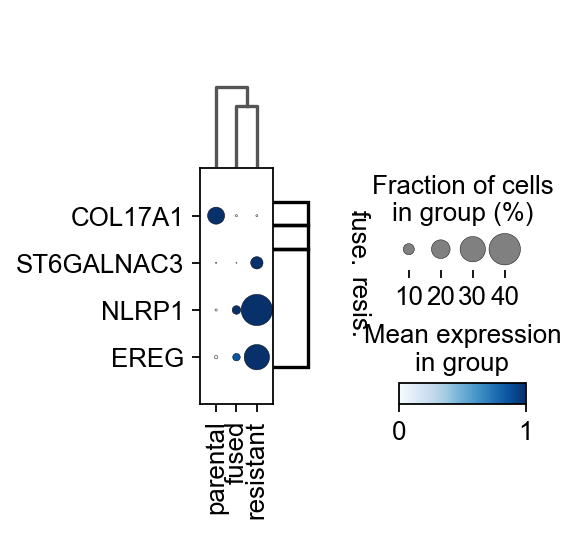

In [41]:
sc.pl.dotplot(
    adata_combined_filtered,
    markers,
    groupby="sample",
    dendrogram=True,
    color_map="Blues",
    swap_axes=True,
    use_raw=True,
    standard_scale="var",
)

KeyError: 'scvi_normalized'